In [9]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torchmetrics
from lightning import Trainer, seed_everything
from lightning.pytorch.callbacks import BatchSizeFinder, ModelCheckpoint, RichModelSummary
from lightning.pytorch.loggers import CSVLogger
from ovito.data import DataCollection
from ovito.io import export_file, import_file
from torch import Tensor
from torch_geometric.loader import NeighborLoader
from tqdm.auto import tqdm

sys.path.append("../..")

from src import LightningDataset, Module
from src.constants import DEFAULT_SEED
from src.graph import PeriodicKNN
from src.transforms import BoxStrain, RandomPerturbation
from src.typing import PathLike

In [10]:
torch.serialization.add_safe_globals([RandomPerturbation, BoxStrain])

In [11]:
torch.set_float32_matmul_precision("medium")
torch.backends.cudnn.benchmark = True
seed_everything(DEFAULT_SEED)

Seed set to 42


42

In [12]:
EPOCHS: int = 50
NUM_NEIGHBORS: int = 20
COMPILE: bool = True
CKPT_NAME: PathLike | None = None
TO_PREDICT: list[PathLike] = []

To mitigate overfittting and improve generalization, we can apply data augmentations to the training data. Here, we use three augmentations designed for atomistic data:
1. RandomPerturbation: Adds gaussian noise to the atomic positions, simulating thermal vibrations.
3. BoxStrain: Randomly strains the simulation box, simulating various types of deformations.

In this example, we use a pick a random standard deviation in the range of (0.0, 0.05) for each augmentation (the standard deviation will be different for each batch) to ensure that the transformations are subtle and do not distort the data too much, while still providing enough variability to help the model learn more robust features.

Note that the specific parameters for each augmentation can be tuned based on the dataset and the desired level of augmentation. For example, it might be sufficient to only apply box strain along z, xz, and yz if you're solely working on tensile deformations along that axis.

Since the provided silicon dataset is quite imbalanced, we enable imbalance sampling to over-sample the less represented classes. We also split our dataset in 3 parts. This is crucial to ensure a model generalizes well to new, unseen data. This "hold-out" strategy prevents the model from simply memorizing (overfitting) the training data and is commonly used in supervised machine-learning. Here, we decided to use 70% of the dataset for training, 20% for validation, and 10% for testing.

In [13]:
augmentations = [
    RandomPerturbation(std_range=(0.0, 0.05)),
    BoxStrain(
        std_range=(0.0, 0.05),
        directions="all",
    ),
]

datamodule = LightningDataset(
    dataset_name="custom",
    lengths=(0.7, 0.2, 0.1),
    root="data",
    transforms=augmentations,
    k=NUM_NEIGHBORS,
    num_workers=8,
    batch_size=512,
    use_imbalance_sampler=True,
)

In PyTorch Lightning, the Trainer class acts as the "project manager", connecting the model and data logic to the underlying hardware (CPU, GPU, ...) while handling background tasks like checkpointing and validation. It is also used to run the training loop, saving checkpoints, logging...

In this example, we want the trainer to:
1. Print a summary of the model architecture.
2. Find the optimal batch size before training starts (will override the batch size defined above!).
3. Log the training metrics in a CSV file. Other loggers, such as TensorBoard, are available.
4. Save the best checkpoint based on the minimum validation loss.
5. Use mixed precision if a GPU is available for faster training and reduced memory usage.
6. Enable the progress bar to monitor training progress.

Of course, these settings can be adjusted based on your specific needs and preferences. You can refer to the PyTorch Lightning documentation for more details on available callbacks and trainer options: https://pytorch-lightning.readthedocs.io/en/stable/api/pytorch_lightning.Trainer.html

Note that changing the batch size will also change the optimal learning rate, which is NOT adjusted accordingly in this example (we are using a learning rate adapted for a batch size of 512). You can try to disable this callback to see how it effects learning.

In [ ]:
callbacks = [
    RichModelSummary(max_depth=2),
    BatchSizeFinder(init_val=128, max_trials=5, mode="power"),
    ModelCheckpoint(monitor="val/loss", mode="min", every_n_epochs=1, save_weights_only=True),
]

loggers = [
    CSVLogger(save_dir="."),
]

trainer = Trainer(
    max_epochs=EPOCHS,
    precision="bf16-mixed" if torch.cuda.is_available() else 32,
    callbacks=callbacks,
    logger=loggers,
    enable_progress_bar=True,
    enable_model_summary=False,
    log_every_n_steps=1,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In this final initialization stage, we prepare our model before training. Optionally, we can load a pre-trained checkpoint to continue training or perform inference on new data. Let's break down the different part of the code.

First, we define the different metrics we will monitor during training. Here, we choose to check the accuracy (fraction of correct predictions), the F1 score (the mean of the precision (exactness) and recall (completeness)), and AUROC (measure the ability of the model to distinguish between classes). Note that the loss is not included as a metric but will be computed anyway since it is necessary for training a neural network.

Then, we check if a checkpoint was the provided. If not, then we initialize a new model. The parameters provided here allow to reach close to perfect accuracy on this dataset with minimum computational time. Feel free to play with the different parameters to understand how they influence the results.

While multiple model architectures are provided, we use a modified PaiNN architecture (Schütt et al., International Conference on Machine Learning (2021)) that allows to use vectorial features (i.e, direction vectors) in an equivariant manner, resulting in cheap and accurate models.

In [15]:
num_classes = datamodule.num_classes
metrics = torchmetrics.MetricCollection(
    {
        "acc": torchmetrics.Accuracy(task="multiclass", num_classes=num_classes),
        "f1": torchmetrics.F1Score(task="multiclass", num_classes=num_classes),
        "auroc": torchmetrics.AUROC(task="multiclass", num_classes=num_classes),
    }
)

should_train = CKPT_NAME is None or not Path(CKPT_NAME).exists()
if should_train:
    with trainer.init_module():
        model = Module(
            model_name="PaiNN",
            num_classes=num_classes,
            metrics=metrics,
            compile=COMPILE,
            warmup=400,
            lr=0.004678965862088063,
            max_iters=EPOCHS * len(datamodule.train_dataloader()),
            model_kwargs={
                "num_radial": 8,
                "hidden_channels": 32,
                "num_layers": 2,
                "dropout": 0.5,
                "scale_factor": 1.0 / math.sqrt(NUM_NEIGHBORS),
            },
        )
else:
    assert CKPT_NAME is not None

    print(f"Loading checkpoint weights from: {CKPT_NAME}")
    with trainer.init_module(empty_init=True):
        model = Module.load_from_checkpoint(CKPT_NAME)

Now that we defined our dataset and model, we can finally train it! After the training ends, we use the best model checkpoint to perform 1 epoch on the validation and test sets to ensure the model generalize well to unseen data.

In [16]:
# type: ignore
if should_train:
    trainer.fit(model=model, datamodule=datamodule, weights_only=False)
    trainer.validate(ckpt_path="best", datamodule=datamodule)
    trainer.test(ckpt_path="best", datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 128 succeeded, trying batch size 256
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 256 succeeded, trying batch size 512
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 512 succeeded, trying batch size 1024
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 1024 succeeded, trying batch size 2048
`Trainer.fit` stopped: `max_steps=3` reached.
Finished batch size finder, will continue with full run using batch size 2048
Restoring states from the checkpoint path at /home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/examples/silicon/.scale_batch_size_c9ca3a90-ac50-4273-ab0d-8b430f5c650d.ckpt
Restored all states from the checkpoint at /home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/examples/silicon/.scale_batch_size_c9ca3a90-ac50-4273-ab0d-8b430f5c650d.ckpt
/home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/.venv/

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                 ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model                │ PaiNN              │ 29.1 K │ train │     0 │
│ 1  │ model.embedding      │ Embedding          │  3.8 K │ train │     0 │
│ 2  │ model.rbf            │ PaiNNRadial        │    872 │ train │     0 │
│ 3  │ model.message_blocks │ ModuleList         │  8.5 K │ train │     0 │
│ 4  │ model.update_blocks  │ ModuleList         │ 14.7 K │ train │     0 │
│ 5  │ model.head           │ PaiNNHead          │  1.2 K │ train │     0 │
│ 6  │ train_metrics        │ MetricCollection   │      0 │ train │     0 │
│ 7  │ train_metrics.acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 8  │ train_metrics.auroc  │ MulticlassAUROC    │      0 │ train │     0 │
│ 9  │ train_metrics.f1     │ MulticlassF1Score  │      0 │ train │     0 │
│ 10 │ val_metrics          │ MetricCollection   │      0 │ train │     0 │
│ 11 │ val_metrics.acc      │ MulticlassAccuracy │      0 │ train │     0 │
│ 12 │ val_metrics.auroc    │ MulticlassAUROC    │      0 │ train │     0 │
│ 13 │ val_metrics.f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 14 │ test_metrics         │ MetricCollection   │      0 │ train │     0 │
│ 15 │ test_metrics.acc     │ MulticlassAccuracy │      0 │ train │     0 │
│ 16 │ test_metrics.auroc   │ MulticlassAUROC    │      0 │ train │     0 │
│ 17 │ test_metrics.f1      │ MulticlassF1Score  │      0 │ train │     0 │
└────┴──────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 29.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 29.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 56                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at /home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/examples/silicon/.scale_batch_size_c9ca3a90-ac50-4273-ab0d-8b430f5c650d.ckpt


Output()

...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val/acc          │   0.006979702971875668    │
│         val/auroc         │    0.5687374472618103     │
│          val/f1           │   0.006979702971875668    │
│         val/loss          │    1.6669293642044067     │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at ./lightning_logs/version_3/checkpoints/epoch=0-step=10.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./lightning_logs/version_3/checkpoints/epoch=0-step=10.ckpt
`weights_only` was not set, defaulting to `False`.
The batch size 2048 is greater or equal than the length of your dataset: 1224.
The batch size 2048 is greater or equal than the length of your dataset: 1224.
Finished batch size finder, will continue with full run using batch size 2048
Restoring states from the checkpoint path at /home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/examples/silicon/.scale_batch_size_a2c85bb5-ebd3-452a-9c37-d0923d7defc4.ckpt
Loaded model weights from the checkpoint at /home/ghuynh/THESE/CLASSIFICATION/Lightning-CEGANN2/examples/silicon/.scale_batch_size_a2c85bb5-ebd3-452a-9c37-d0923d7defc4.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │   0.008580970577895641    │
│        test/auroc         │     0.560969352722168     │
│          test/f1          │   0.008580970577895641    │
└───────────────────────────┴───────────────────────────┘

Let's see if our model learned correctly. For that, we can plot the different metrics we computed during training and validation. Ideally, the accuracy, F1 score and AUROC must converge to 1, while the loss must go to 0. The best model is usually the one that yields the best validation metrics. In our case, you might remember that we defined our best model as the one with the lowest validation loss.

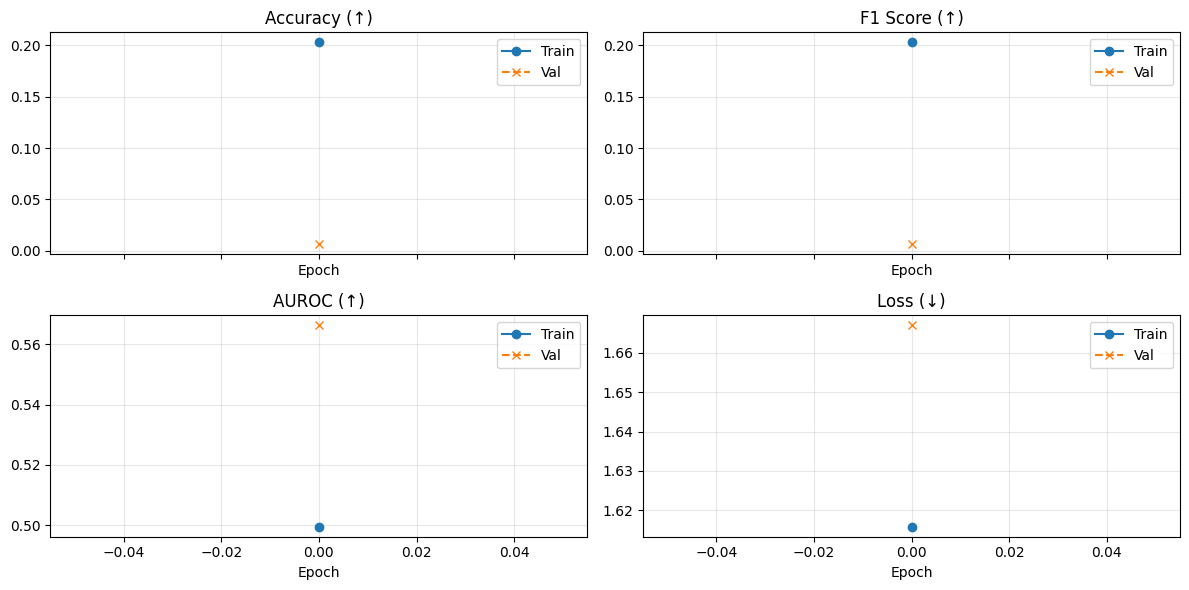

In [17]:
def plot_metrics(trainer: Trainer) -> None:
    """Plot training and validation curves for accuracy, F1 score, AUROC, and loss.

    Args:
        trainer: The PyTorch Lightning Trainer object after training is complete.
    """
    if not (trainer.logger and trainer.logger.log_dir):
        print(
            "No logger or log directory, skipping training curves visualization. "
            "Make sure to use a logger that saves metrics to a file (e.g., CSVLogger)."
        )
        return

    metric_path = Path(trainer.logger.log_dir) / "metrics.csv"
    if not metric_path.exists():
        print(f"No metrics file found at {metric_path}, skipping training curves visualization.")
        return

    df = pd.read_csv(metric_path)

    # We are logging every n steps during training, so we average
    # the metrics per epoch to get a single value per epoch
    df = df.groupby("epoch").mean(numeric_only=True)

    # Define the metric pairs we want to visualize
    metric_groups = [
        ("Accuracy (↑)", "train/acc", "val/acc"),
        ("F1 Score (↑)", "train/f1", "val/f1"),
        ("AUROC (↑)", "train/auroc", "val/auroc"),
        ("Loss (↓)", "train/loss", "val/loss"),
    ]

    # Filter out metric groups where neither training nor validation metric is available
    available_plots = [p for p in metric_groups if p[1] in df.columns or p[2] in df.columns]

    _, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

    for ax, (title, t_col, v_col) in zip(axes.flat, available_plots):
        # Train metric
        if t_col in df.columns:
            train_data = df[t_col].dropna()
            ax.plot(train_data.index, train_data, label="Train", linestyle="-", marker="o")

        # Validation metric
        if v_col in df.columns:
            val_data = df[v_col].dropna()
            ax.plot(val_data.index, val_data, label="Val", linestyle="--", marker="x")

        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if should_train:
    plot_metrics(trainer)
else:
    print("Model was loaded from checkpoint, skipping training curves visualization.")

In this final section of this tutorial, we move from training to inference. We will see how we can run our trained model on very large systems and how we can save the results to a format compatible with visualization tools such as OVITO. Note that we also provide an OVITO Python modifier that you can download and run directly from the OVITO software!

To enable fast inference, we make use of PyTorch Geometric's NeighborLoader class that allow us quickly process large graphs while avoiding the neighborhood explosion when the number of layers increase. In a message-passing neural network like used here, each layer expands the reach of a single atom. For a model with *L* layers and *k* neighbors, we will have to compute the embeddings of $\sum\limits_{i=0}^{L} k^i$ atoms for each central atom! When using hierarchical neighborhood sampling, we can significantly reduce the number of computations required by progressively "trimming" the graph as it passes through each layer. The core insight behind this technique is that nodes sampled in the later "hops" of the neighborhood are only necessary for the initial message-passing layers. As the data flows deeper into the GNN, these distant nodes no longer contribute to the final representation of the central seed atom. This allow us to progressively trim the graph as it passes through each layer.

In [18]:
@torch.inference_mode()
def inference(model: Module, data: DataCollection) -> Tensor:
    model.eval()
    device = next(model.parameters()).device
    num_layers: int = model.model.num_layers  # type: ignore

    knn = PeriodicKNN(k=NUM_NEIGHBORS)
    graph = knn.convert(data)

    loader = NeighborLoader(
        graph,
        num_neighbors=[-1] * num_layers,
        batch_size=min(2**16, graph.num_nodes),  # type: ignore
        shuffle=False,
        num_workers=8,
        persistent_workers=True,
        pin_memory=True,
        prefetch_factor=2,
    )

    graph_preds = []
    for batch in tqdm(loader, unit="batch", total=len(loader)):
        batch = batch.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            out = model.predict_step(batch)
        graph_preds.append(out.to("cpu", non_blocking=True))

    torch.cuda.synchronize()
    predictions = torch.cat(graph_preds, dim=0)

    return predictions


def dump_outputs(
    preds: Tensor,
    data: DataCollection,
    fpath: PathLike,
) -> None:
    path = Path(fpath)
    out_path = path.with_name(f"{path.stem}_predicted.extxyz")

    pred_array = preds.detach().cpu().numpy()
    data.particles_.create_property("Prediction", data=pred_array)

    export_file(
        data,
        str(out_path),
        "xyz",
        columns=[
            "Particle Identifier",
            "Particle Type",
            "Position.X",
            "Position.Y",
            "Position.Z",
            "Prediction",
        ],
    )
    print(f"Saved predictions to {out_path}")


if TO_PREDICT:
    for path in tqdm(TO_PREDICT):
        data = import_file(path).compute()
        preds = inference(model, data)
        dump_outputs(preds, data, path)
else:
    print("No files specified for prediction.")

No files specified for prediction.
